# multi-output neural network

In [3]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# If you want to check details about the GPU
# print(tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
Num GPUs Available: 1


In [5]:
# installer les packages necessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# charger le dataset
pizza_types = pd.read_csv('/content/pizza_types.csv', index_col=0)

In [8]:
pizza_types.head(10)

,corn,olives,mushrooms,spinach,pineapple,artichoke,chilli,pepper,onion,mozzarella,egg,pepperoni,beef,chicken,bacon,vegan,vegetarian,meaty
0,False,True,False,True,False,False,True,False,False,False,True,True,True,False,False,False,False,True
1,True,False,False,True,False,False,True,False,False,True,False,True,True,True,False,False,False,True
2,False,False,False,True,False,True,False,True,False,True,False,False,True,False,True,False,False,True
3,False,True,True,False,False,False,True,False,False,True,False,True,True,False,False,False,False,True
4,False,True,False,False,True,True,False,False,False,True,True,True,True,False,False,False,False,True
5,False,False,False,False,True,False,False,True,True,False,True,True,False,False,False,False,False,True
6,False,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,True
7,True,False,False,False,False,False,False,False,True,True,False,False,True,False,False,False,False,True
8,True,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True
9,True,False,False,False,False,False,True,True,False,True,False,False,True,True,False,False,False,True


In [9]:
pizza_types.shape

(5520, 18)

Let's split them into an 80% training dataset and a 20% testing dataset.

In [10]:
training_dataset = pizza_types.sample(frac=0.8)
testing_dataset = pizza_types[~pizza_types.index.isin(training_dataset.index)]

In [11]:
# chek to see if the splitv was done directly
training_dataset.shape

(4416, 18)

In [12]:
testing_dataset.shape

(1104, 18)

Set Up and Train Your First Multi-Output Neural Network

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

pizza_type_model = Sequential()
pizza_type_model.add(Dense(3, input_dim=15, activation='softmax'))

sgd = SGD()

pizza_type_model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

pizza_type_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            48 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48 (192.00 B)

 Trainable params: 48 (192.00 B)

 Non-trainable params: 0 (0.00 B)

Training your data

In [15]:
history_sgd_pizza_type_model = pizza_type_model.fit(
    training_dataset[['corn', 'olives', 'mushrooms', 'spinach', 'pineapple', 'artichoke', 'chilli', 'pepper', 'onion', 'mozzarella', 'egg', 'pepperoni', 'beef', 'chicken', 'bacon',]],
    training_dataset[['vegan', 'vegetarian', 'meaty']],
    epochs=200,
    validation_split=0.2,
)

Epoch 1/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4025 - loss: 1.1766 - val_accuracy: 0.9140 - val_loss: 0.4612
Epoch 2/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9118 - loss: 0.4158 - val_accuracy: 0.9186 - val_loss: 0.3225
Epoch 3/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9111 - loss: 0.3233 - val_accuracy: 0.9186 - val_loss: 0.2843
Epoch 4/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9046 - loss: 0.3134 - val_accuracy: 0.9186 - val_loss: 0.2664
Epoch 5/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9033 - loss: 0.2978 - val_accuracy: 0.9186 - val_loss: 0.2553
Epoch 6/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9052 - loss: 0.2833 - val_accuracy: 0.9186 - val_loss: 0.2469
Epoch 7/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9164 - loss: 0.2551 - val_accuracy: 0.9186 - val_loss: 0.2400
Epoch 8/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9164 - loss: 0.2471 - val_acc

Evaluate the model

In [16]:
test_loss, test_acc = pizza_type_model.evaluate(
    testing_dataset[['corn', 'olives', 'mushrooms', 'spinach', 'pineapple', 'artichoke', 'chilli', 'pepper', 'onion', 'mozzarella', 'egg', 'pepperoni', 'beef', 'chicken', 'bacon',]],
    testing_dataset[['vegan', 'vegetarian', 'meaty']]
)

print(f"Evaluation result on Test Data : Loss = {test_loss}, accuracy = {test_acc}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0492
Evaluation result on Test Data : Loss = 0.048998259007930756, accuracy = 1.0


change the optimizer SGD(stochastic gradient descent ) and use Adam. Whereas SGD maintained its learning rate during the training session, Adam varies it based on how the algorithm is learning, making training much faster.

In [17]:
from tensorflow.keras.optimizers import Adam

In [18]:
pizza_type_model = Sequential()

pizza_type_model.add(Dense(3, input_dim=15, activation='softmax'))

adam = Adam()

pizza_type_model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])

pizza_type_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 3)              │            48 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48 (192.00 B)

 Trainable params: 48 (192.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_adam_pizza_type_model = pizza_type_model.fit(
    training_dataset[['corn', 'olives', 'mushrooms', 'spinach', 'pineapple', 'artichoke', 'chilli', 'pepper', 'onion', 'mozzarella', 'egg', 'pepperoni', 'beef', 'chicken', 'bacon',]],
    training_dataset[['vegan', 'vegetarian', 'meaty']],
    epochs=200,
    validation_split=0.2,
)

Epoch 1/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5174 - loss: 0.9793 - val_accuracy: 0.8416 - val_loss: 0.5882
Epoch 2/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8447 - loss: 0.5555 - val_accuracy: 0.9174 - val_loss: 0.4019
Epoch 3/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8982 - loss: 0.4100 - val_accuracy: 0.9186 - val_loss: 0.3355
Epoch 4/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9073 - loss: 0.3410 - val_accuracy: 0.9186 - val_loss: 0.3047
Epoch 5/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9119 - loss: 0.3051 - val_accuracy: 0.9186 - val_loss: 0.2858
Epoch 6/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9138 - loss: 0.2883 - val_accuracy: 0.9186 - val_loss: 0.2716
Epoch 7/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9089 - loss: 0.2843 - val_accuracy: 0.9186 - val_loss: 0.2595
Epoch 8/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9145 - loss: 0.2628 - val_acc

Let's compare the training history when using SGD and Adam:

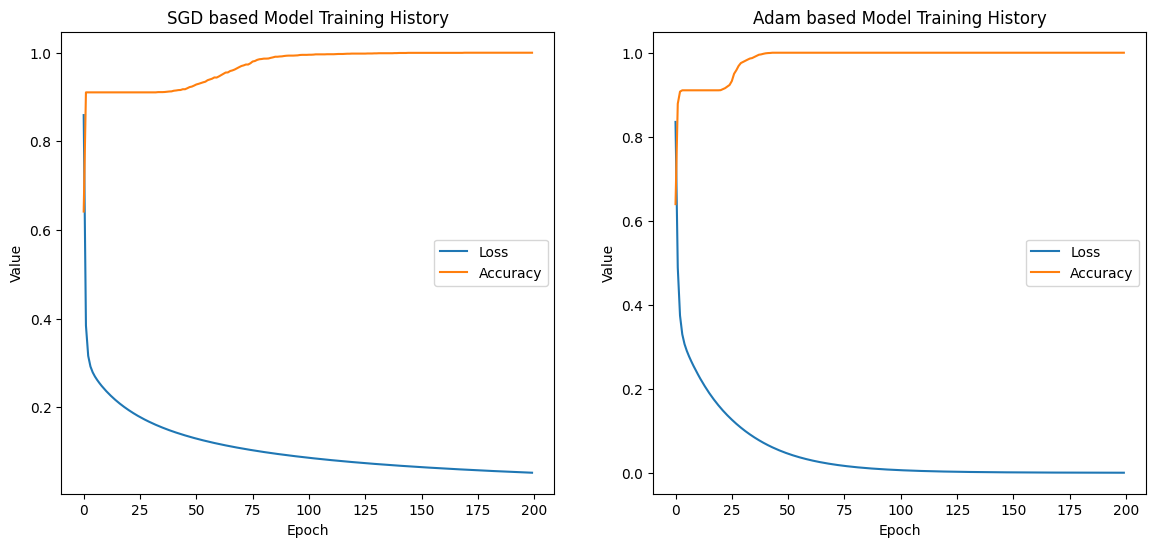

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes = axes.flatten()

axes[0].plot(history_sgd_pizza_type_model.history['loss'])
axes[0].plot(history_sgd_pizza_type_model.history['accuracy'])
axes[0].set_title('SGD based Model Training History')
axes[0].set_ylabel('Value')
axes[0].set_xlabel('Epoch')
axes[0].legend(['Loss', 'Accuracy'], loc='center right')
axes[1].plot(history_adam_pizza_type_model.history['loss'])
axes[1].plot(history_adam_pizza_type_model.history['accuracy'])
axes[1].set_title('Adam based Model Training History')
axes[1].set_ylabel('Value')
axes[1].set_xlabel('Epoch')
axes[1].legend(['Loss', 'Accuracy'], loc='center right')
plt.show()

Loss (the blue line) - with SGD, it reaches 0 after approximately 200 iterations; however, when using Adam, it reaches 0 after around 100 iterations.

# Train a Deeper Fully Connected Neural Network

In [22]:
traffic_data = pd.read_csv('/content/traffic_data.csv', index_col=0)

In [23]:
traffic_data.head()

,day,minute,hour,second,type
0,Monday,0,8,14,traffic
1,Monday,0,8,28,traffic
2,Monday,0,8,34,traffic
3,Monday,0,8,45,traffic
4,Monday,0,8,53,traffic


In [25]:
traffic_data.shape

(85638, 5)

In [26]:
traffic_data['type'].value_counts()

,count
type,
no_traffic,50769
traffic,34869


The dataset is imbalanced; there is more data when there is no traffic, but you will manage!

In [27]:
traffic_data['day'].value_counts()

,count
day,
Sunday,12278
Saturday,12251
Thursday,12241
Wednesday,12237
Tuesday,12217
Monday,12212
Friday,12202


There is a relatively equal representation of data every day. How about the traffic vs. non-traffic variable per day?

In [28]:
traffic_data.groupby('day')['type'].value_counts()

day        type      
Friday     traffic        6989
           no_traffic     5213
Monday     traffic        6972
           no_traffic     5240
Saturday   no_traffic    12251
Sunday     no_traffic    12278
Thursday   traffic        6965
           no_traffic     5276
Tuesday    traffic        6990
           no_traffic     5227
Wednesday  traffic        6953
           no_traffic     5284
Name: count, dtype: int64

There is a relatively equal traffic vs. no-traffic representation besides Saturdays and Sundays. What about per hour?

In [29]:
traffic_data['hour'].value_counts()

,count
hour,
8,6211
16,6204
20,6195
18,6188
14,6180
10,6156
12,6147
15,6110
17,6076


In [30]:
traffic_data['c_type'] = traffic_data['type'].apply(lambda x: 1 if x == 'traffic' else 0)

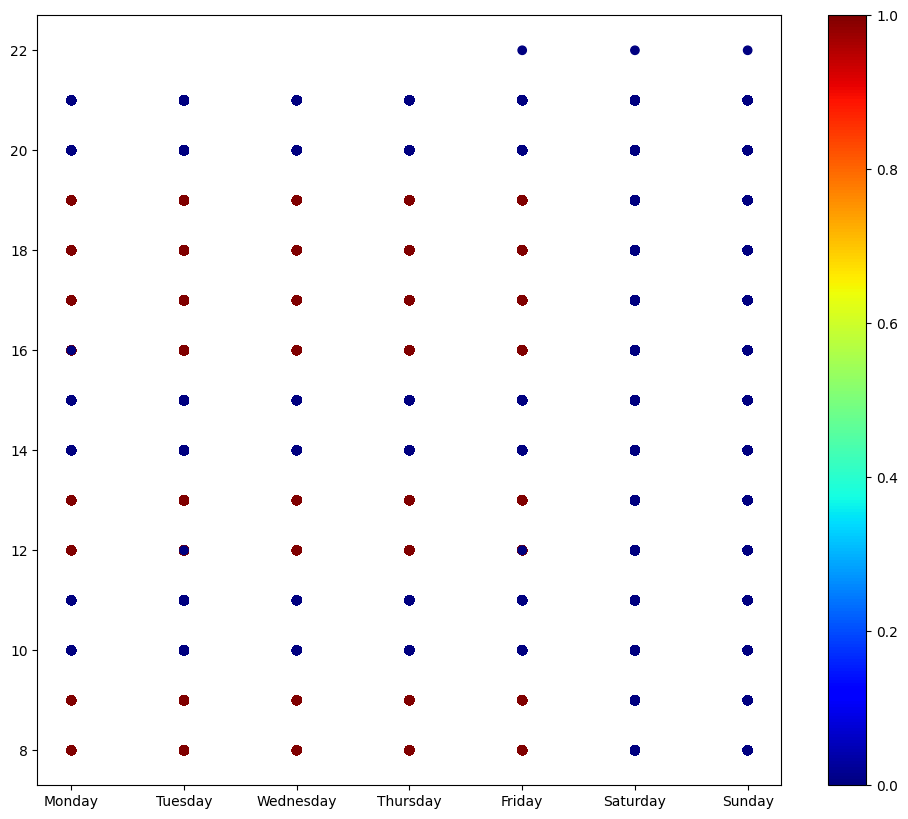

In [34]:
# visualize data
import matplotlib.pyplot as plt

from matplotlib.pyplot import colorbar, figure

figure(num=None, figsize=(12, 10))

plt.scatter(
    traffic_data['day'],
    traffic_data['hour'],
    c=traffic_data['c_type'],
    cmap='jet'
)

cbar = colorbar()

As seen before, there is no traffic on Saturdays or Sundays. It seems to be mostly around some key hours, such as 8-10, 12-13, and 16-20.

Let's first convert the days to new columns using one-hot encoding:

In [35]:
traffic_data = traffic_data.join(pd.get_dummies(traffic_data['day']))

Split the data again into a training and test set:

In [36]:
training_dataset = traffic_data.sample(frac=0.8)
testing_dataset = traffic_data[~traffic_data.index.isin(training_dataset.index)]

In [43]:
# select the input columns you will be using
input_columns = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'hour', 'minute','second']

Set Up Your First Neural Network With a Hidden Layer

Use ReLu function because deep neural networks can suffer from a phenomenon called gradient vanishing.  

Gradient vanishing is a phenomenon that happens when the error that backpropagation pushes back throughout the network gets smaller and smaller as it moves from right to left (output layer towards input layer).

In [38]:
from tensorflow.keras.layers import Dropout

In [45]:
traffic_model = Sequential([
    Dense(30, input_dim=len(input_columns), activation='relu'),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

adam = Adam()

traffic_model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

traffic_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,355 (5.29 KB)

 Trainable params: 1,355 (5.29 KB)

 Non-trainable params: 0 (0.00 B)

The batch size represents how many examples the algorithm predicts during training before the weights get updated.

In [46]:
batch_size = 100

In [48]:
history_traffic_model = traffic_model.fit(
   training_dataset[input_columns].astype(int),
   training_dataset[['c_type']],
   epochs=30,
   validation_split=0.1,
   batch_size=batch_size
)

Epoch 1/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5445 - loss: 0.9650 - val_accuracy: 0.6037 - val_loss: 0.6403
Epoch 2/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6146 - loss: 0.6275 - val_accuracy: 0.6992 - val_loss: 0.5071
Epoch 3/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6803 - loss: 0.5177 - val_accuracy: 0.6993 - val_loss: 0.4828
Epoch 4/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6867 - loss: 0.4969 - val_accuracy: 0.7238 - val_loss: 0.4712
Epoch 5/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7064 - loss: 0.4836 - val_accuracy: 0.7265 - val_loss: 0.4694
Epoch 6/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7349 - loss: 0.4687 - val_accuracy: 0.7802 - val_loss: 0.4328
Epoch 7/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7603 - loss: 0.4412 - val_accuracy: 0.7790 - val_loss: 0.3947
Epoch 8/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7715 - loss: 0.4069 - val_accuracy: 0.

Evaluate the model

In [50]:
test_loss_traffic, test_acc_traffic = traffic_model.evaluate(
    testing_dataset[input_columns].astype(int),
    testing_dataset[['c_type']]
)

print(f"Evaluation result on Test Data: Loss = {test_loss_traffic}, accuracy = {test_acc_traffic}")

536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9781 - loss: 0.1244
Evaluation result on Test Data: Loss = 0.10505125671625137, accuracy = 0.9767048358917236
